                     track_id  \
0      6f807x0ima9a1j3VPbc7VN   
1      0r7CVbZTWZgbTCYdfa2P31   
2      1z1Hg7Vb0AhHDiEmnDE79l   
3      75FpbthrwQmzHlBJLuGdC7   
4      1e8PAfcKUYoKkxPhrHqw4x   
...                       ...   
32828  7bxnKAamR3snQ1VGLuVfC1   
32829  5Aevni09Em4575077nkWHz   
32830  7ImMqPP3Q1yfUHvsdn7wEo   
32831  2m69mhnfQ1Oq6lGtXuYhgX   
32832  29zWqhca3zt5NsckZqDf6c   

                                              track_name      track_artist  \
0      I Don't Care (with Justin Bieber) - Loud Luxur...        Ed Sheeran   
1                        Memories - Dillon Francis Remix          Maroon 5   
2                        All the Time - Don Diablo Remix      Zara Larsson   
3                      Call You Mine - Keanu Silva Remix  The Chainsmokers   
4                Someone You Loved - Future Humans Remix     Lewis Capaldi   
...                                                  ...               ...   
32828               City Of Lights - Official Radio Edit 

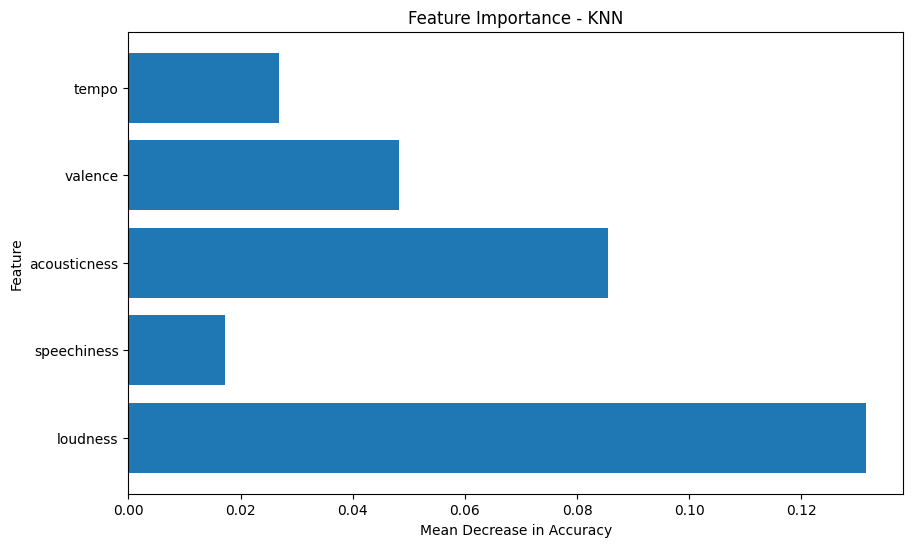

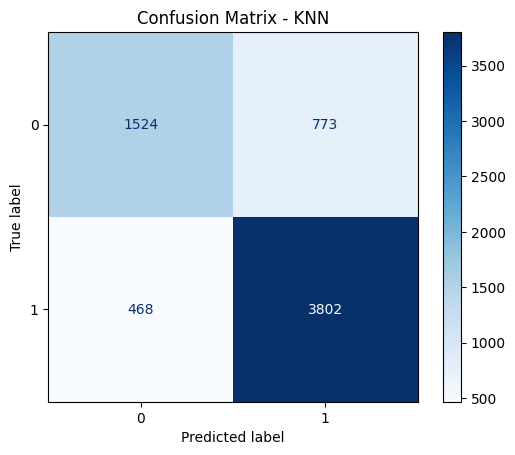

In [ ]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Loading the dataset
df = pd.read_csv('spotify_songs.csv')

df['energy'] = np.where(df['energy'] < 0.65, 0, 1)
df['energy'] = df['energy'].astype('category')

print(df)

# Min-max scaling function
def min_max_scale(x):
    return (x - x.min()) / (x.max() - x.min())

# Select columns to normalize
columns_to_normalize = ["loudness", "speechiness", "acousticness", "tempo"]

# Apply min-max scaling to selected columns
df[columns_to_normalize] = df[columns_to_normalize].apply(min_max_scale)

print(df)

# Splitting the dataset into training and testing partition
X = df[["loudness", "speechiness", "acousticness", "valence", "tempo"]]
y = df["energy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn_model = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': range(1, 11)},
    cv=5,
    scoring='accuracy'
)

!pip install scikit-learn
from sklearn.impute import SimpleImputer

# Create an imputer (e.g., using the mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both train and test data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Continue with model training
knn_model.fit(X_train, y_train)
print(knn_model.cv_results_)

# Best model with tuned hyperparameters
best_k = knn_model.best_params_['n_neighbors']
print(f"Best k: {best_k}")

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

knn_predictions = best_model.predict(X_test)

# Building and printing the confusion matrix
knn_confusion_matrix = confusion_matrix(y_test, knn_predictions)
print(knn_confusion_matrix)

# Calculate Accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)

# Calculate Precision
knn_precision = precision_score(y_test, knn_predictions)

# Calculate Recall
knn_recall = recall_score(y_test, knn_predictions)

# Calculate F1 Score
knn_f1 = f1_score(y_test, knn_predictions)

# Results
print(f"Accuracy: {knn_accuracy}")
print(f"Precision: {knn_precision}")
print(f"Recall: {knn_recall}")
print(f"F1 Score: {knn_f1}")

from sklearn.inspection import permutation_importance

# Calculate permutation importance
result = permutation_importance(best_model, X_test, y_test, n_repeats=30, random_state=42, scoring='accuracy')

# Get the importance values and feature names
importance_means = result.importances_mean
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_means, align='center')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.title('Feature Importance - KNN')
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=knn_confusion_matrix, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - KNN")
plt.show()


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 11)}, scoring='accuracy')